## LangChain Basics – From LLM Calls to RAG

### 🎯 Why This Notebook?

Before we jump into the deeper waters of **RAG pipelines** and **Agents**, this notebook will help you warm up with the essential building blocks of LangChain.

You’ll go from:
<br>
🔹 Making a basic **LLM call**
<br>
🔹 Using a **prompt template**
<br>
🔹 Creating **chains** by combining components
<br>
🔹 And finally, building a working **RAG pipeline** : where the LLM answers questions from real documents (not its training data)

This is your playground to build **intuition** before we dive deeper in the live session.

---

### 🧠 Core Concepts at a Glance

#### 🔹 LLM Call
A direct call to an LLM like GPT-4. You give it a prompt, and it gives you an answer. It’s like talking to ChatGPT behind the scenes.

<br>

#### 🔹 Prompt Template
A reusable way to structure inputs. You can insert variables like `{input}` or `{context}` dynamically — great for consistency and modularity.

<br>

#### 🔹 Chain
LangChain allows you to connect components together. For example, a **Prompt** → **LLM** → **Output Parser** can be combined into a single "chain" that flows from input to output.

<br>

#### 🔹 RAG (Retrieval-Augmented Generation)
Instead of relying only on the LLM’s memory, RAG lets us bring in **external knowledge**.

It works like this:
- A **retriever** pulls relevant document chunks from a vector database
- These are inserted into a prompt template as **context**
- The **LLM** is then asked to answer based only on that context

This is powerful for use cases like:
- Chatbots over documentation
- Q&A on company wikis or PDFs
- Smart search assistants

---

### Installing Packages

In [1]:

%pip install langchain langchain-core langchain-community langchain_openai faiss-cpu sentence-transformers
%pip install langchain-classic


  Using cached langchain_openai-1.3.5-py3-none-any.whl.metadata (3.4 kB)
  Using cached tiktoken-0.13.0-cp314-cp314-win_amd64.whl.metadata (6.8 kB)
Using cached langchain_openai-1.3.5-py3-none-any.whl (121 kB)
Using cached tiktoken-0.13.0-cp314-cp314-win_amd64.whl (918 kB)

   -------------------- ------------------- 1/2 [langchain_openai]
   -------------------- ------------------- 1/2 [langchain_openai]
   -------------------- ------------------- 1/2 [langchain_openai]
   ---------------------------------------- 2/2 [langchain_openai]

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


### Setting Up API Access

In [2]:
import os
import getpass

os.environ["OPENROUTER_API_KEY"] = getpass.getpass("Enter OpenRouter API Key: ")


#### Code Explanation:

`getpass.getpass()` safely asks for your OpenAI API key without showing it on the screen.

`LANGCHAIN_TRACING_V2 = "true"` turns on a useful tracking tool that helps you see what your LangChain app is doing step-by-step. Super helpful for debugging or understanding how the pieces work together.
Think of it like switching on a "behind-the-scenes" camera for your LLM workflows.

In [3]:
# OpenRouter LLM
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(
    model="openai/gpt-4o-mini",
    temperature=0,
    max_tokens = 150,
    openai_api_key=os.environ["OPENROUTER_API_KEY"],
    base_url="https://openrouter.ai/api/v1"
)


### Simple LLM Call

In [4]:
answer = llm.invoke("what is your cuttoff date")
print(answer.content)

My knowledge is based on information available up until October 2021. If you have questions or need information up to that date, feel free to ask!


In [ ]:
# List of models to try if above doesn't work


# "mistralai/mistral-7b-instruct",
# "meta-llama/llama-3.1-8b-instruct",
# "google/gemma-7b-it",
# "x-ai/grok-2-mini"
# "deepseek/deepseek-r1:free",
# "poolside/laguna-xs.2:free",


### Explanation:

`ChatOpenAI` is LangChain’s wrapper around OpenAI’s chat models (like GPT-3.5 or GPT-4).

We’re creating an LLM instance (llm) that’s ready to receive prompts and return responses.

The api_key is securely pulled from your environment (as set earlier), so you don’t have to hardcode secrets.

* You’re sending a prompt directly to the LLM using `.invoke()`.

* The response is returned as a ChatMessage object — it contains both the content and metadata.

Think of this as a raw "ask-and-answer" interaction with the model.

In [5]:
# Print the LLM's response to the prompt
print(answer)

# Print the type of the response object (useful for understanding the structure of the output)
print(type(answer))

content='My knowledge is based on information available up until October 2021. If you have questions or need information up to that date, feel free to ask!' additional_kwargs={'refusal': None} response_metadata={'token_usage': {'completion_tokens': 32, 'prompt_tokens': 14, 'total_tokens': 46, 'completion_tokens_details': {'accepted_prediction_tokens': None, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': None, 'image_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': 0, 'cached_tokens': 0, 'video_tokens': 0}, 'cost': 2.13e-05, 'is_byok': False, 'cost_details': {'upstream_inference_cost': 2.13e-05, 'upstream_inference_prompt_cost': 2.1e-06, 'upstream_inference_completions_cost': 1.92e-05}}, 'model_provider': 'openai', 'model_name': 'openai/gpt-4o-mini', 'system_fingerprint': 'fp_965c8b9ecf', 'id': 'gen-1784052954-VvrbRh1tuXY71rIZ2MXB', 'finish_reason': 'stop', 'logprobs': None} id='lc_run--019f61d7-b339-7253-a62d-e7abf672af23-0' tool_

The above prints the full response object and its type; usually a AIMessage from LangChain.

In [6]:
# Print just the textual content of the LLM's response (excluding metadata or other attributes)
print(answer.content)

My knowledge is based on information available up until October 2021. If you have questions or need information up to that date, feel free to ask!


### Output (summarized):
The LLM gives a generic explanation of how a company named "Langsmith" could help with language testing, listing use cases like test platforms, scoring, and prep materials.

### Why This Isn’t Enough
The response is factual but generic — there’s no control, formatting, or customization.
This is why we move on to **Prompt Templates** and **Chaining** to make the outputs richer, structured, and more task-specific.

### Using a Prompt Template

In [ ]:
# Import ChatPromptTemplate to structure multi-turn conversational prompts
from langchain_core.prompts import ChatPromptTemplate

# Define a prompt template with system, human, and AI message roles
template = ChatPromptTemplate.from_messages([
    ("system", "You are a helpful AI bot. Your name is {name}."),
    ("human", "Hello, how are you doing?"),
    ("ai", "I'm doing well, thanks!"),
    ("human", "{user_input}"),
])

# Populate the template with actual variables
prompt_value = template.invoke(
    {
        "name": "Bob",
        "user_input": "What is your name?"
    }
)

### Code Explanation:

* `ChatPromptTemplate` lets you define a structured multi-turn conversation format using roles: system, human, ai.

* Variables like `{name}` and `{user_input}` are placeholders you can fill in dynamically.

* `template.invoke(...)` injects values into the template. Here, name = "Bob" and the user asks a follow-up question.

This helps simulate real conversational context and control how the model is prompted.

In [8]:
# Iterate over the messages in the generated prompt and print the type of each message.
for msg in prompt_value.messages:
  print(type(msg).__name__, ":", msg.content)

SystemMessage : You are a helpful AI bot. Your name is Bob.
HumanMessage : Hello, how are you doing?
AIMessage : I'm doing well, thanks!
HumanMessage : What is your name?


 The above block prints each message in the constructed prompt, showing how the roles (system, human, ai) and variables came together to form a complete, conversational input to the LLM.
Useful for debugging and understanding exactly what the LLM will "see".

In [ ]:
# Import ChatPromptTemplate to define structured chat prompts
from langchain_core.prompts import ChatPromptTemplate

# Create a prompt template with a system message and a placeholder for user input
prompt = ChatPromptTemplate.from_messages([
    ("system", "You are a world class technical documentation writer. Respond in that manner only."), # system instructions
    ("user", "{input}")
])

In [ ]:
for msg in prompt.messages:
  print(type(msg).__name__, ":", msg)

SystemMessagePromptTemplate : prompt=PromptTemplate(input_variables=[], input_types={}, partial_variables={}, template='You are a world class technical documentation writer. Respond in that manner only.') additional_kwargs={}
HumanMessagePromptTemplate : prompt=PromptTemplate(input_variables=['input'], input_types={}, partial_variables={}, template='{input}') additional_kwargs={}


Similarly, the above two blocks sets up a prompt template — this time with a single-turn interaction focused on technical documentation.

### Creating a Simple Chain

In [ ]:
# Create a simple chain by piping the prompt into the LLM
chain = prompt | llm



### Explanation:

* This creates a chain by connecting the `prompt` directly to the `llm` using the `|` operator.

* When invoked, the prompt gets formatted with user input and immediately passed to the LLM.

This modular approach lets you build pipelines that are easy to extend and reuse.

In [ ]:
# Print the first component of the chain (useful for inspecting the pipeline's starting point)
print(chain.first)

input_variables=['input'] input_types={} partial_variables={} messages=[SystemMessagePromptTemplate(prompt=PromptTemplate(input_variables=[], input_types={}, partial_variables={}, template='You are a world class technical documentation writer. Respond in that manner only.'), additional_kwargs={}), HumanMessagePromptTemplate(prompt=PromptTemplate(input_variables=['input'], input_types={}, partial_variables={}, template='{input}'), additional_kwargs={})]


The above shows the first component in the chain — in this case, it’s the full prompt template with structure and placeholders (`{input}`) clearly laid out. Useful for inspecting how your chain starts.

### Running the Chain with Input

In [ ]:
# Invoke the full chain with user input; the prompt is formatted and passed to the LLM
chain_result = chain.invoke({"input": "how can h2o help with testing?"})

#### Explanation:

* This passes a user question into the chain.

* The `{input}` placeholder in the prompt is filled with the actual query.

* The prompt is sent to the LLM, and the final response is stored in `chain_result`.

In [ ]:
print(chain_result) # Print the content of the response generated by the chain

content='H2O is an open-source software for data analysis that provides a suite of tools for machine learning and data processing. When it comes to testing, H2O can be particularly beneficial in several ways:\n\n### 1. **Automated Model Testing**\n   - **Cross-Validation**: H2O supports k-fold cross-validation, allowing users to assess the performance of machine learning models on different subsets of data. This helps in understanding model stability and generalization.\n   - **Grid Search**: H2O facilitates hyperparameter tuning through grid search, enabling users to systematically test various combinations of parameters to optimize model performance.\n\n### 2. **Performance Metrics**\n   - H2O provides a variety of performance metrics (e.g., accuracy' additional_kwargs={'refusal': None} response_metadata={'token_usage': {'completion_tokens': 150, 'prompt_tokens': 35, 'total_tokens': 185, 'completion_tokens_details': {'accepted_prediction_tokens': None, 'audio_tokens': 0, 'reasoning_t

The above prints just the final response text from the chain.
Compared to the earlier raw LLM call, this output is better structured and more task-specific. Thanks to the prompt that positioned the LLM as a technical documentation writer.

In [ ]:
print(chain_result.response_metadata) # Print metadata about the LLM's response (e.g., token usage, model info, etc.)

{'token_usage': {'completion_tokens': 150, 'prompt_tokens': 35, 'total_tokens': 185, 'completion_tokens_details': {'accepted_prediction_tokens': None, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': None, 'image_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': 0, 'cached_tokens': 0, 'video_tokens': 0}, 'cost': 9.525e-05, 'is_byok': False, 'cost_details': {'upstream_inference_cost': 9.525e-05, 'upstream_inference_prompt_cost': 5.25e-06, 'upstream_inference_completions_cost': 9e-05}}, 'model_provider': 'openai', 'model_name': 'openai/gpt-4o-mini', 'system_fingerprint': 'fp_965c8b9ecf', 'id': 'gen-1783750524-pXRNdP3H6XqyUdtvED88', 'finish_reason': 'length', 'logprobs': None}


The above displays metadata about the LLM call — including token usage, model name, and finish reason.
Useful for monitoring cost, performance, and debugging.

### Cleaning Output with an Output Parser

In [ ]:
# Import a parser that extracts plain string content from LLM responses
from langchain_core.output_parsers import StrOutputParser

# Initialize the string output parser
output_parser = StrOutputParser()

In [ ]:
# Create a full chain that formats the prompt, sends it to the LLM, and parses the output into a plain string
chain = prompt | llm | output_parser

* `StrOutputParser()` is added at the end of the chain to cleanly extract just the string/text output from the LLM's response.

* Without this, you'd get a full object (`AIMessage`). With this, you directly get plain text — easy to print, log, or pass to other tools

In [ ]:
# Invoke the updated chain with user input; returns the final parsed string response
chain_result = chain.invoke({"input": "how can langsmith help with testing?"})

In [ ]:
print(chain_result) #print the final plain-text result returned by the chain

LangSmith is a powerful tool designed to enhance the testing process for applications that utilize natural language processing (NLP) and machine learning models. Below are several ways in which LangSmith can assist with testing:

### 1. **Automated Test Generation**
   - **Input Variability**: LangSmith can generate a wide range of input variations to test the robustness of NLP models. This includes paraphrasing, synonym replacement, and altering sentence structures.
   - **Edge Case Identification**: The tool can help identify edge cases that may not be covered by standard test cases, ensuring comprehensive testing.

### 2. **Test Case Management**
   - **Organized Test Suites**: LangSmith allows users to organize test cases into suites, making


### Output Summary
The response is now a well-structured, markdown-friendly explanation of how Langsmith can help in testing, with bold headings and bullet points.

Compared to earlier:

* The content quality is preserved, but

* The format is simplified — no wrappers, metadata, or .content access needed.

* Final result: Clean, ready-to-display text, great for UI responses, logging, or piping into downstream logic.
<br>


#### Now we're entering the RAG (Retrieval-Augmented Generation) part of the pipeline.

### Loading External Documents

In [ ]:
# Import a loader to fetch and parse web page content
from langchain_community.document_loaders import WebBaseLoader

# Initialize the web loader with the URL of the LangSmith documentation
loader = WebBaseLoader("https://docs.smith.langchain.com/")

# Load the content from the webpage into a list of Document objects
docs = loader.load()

/tmp/ipykernel_1198/3225703843.py:2: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import WebBaseLoader


### Explanation :

* We use `WebBaseLoader` to scrape and load content from a webpage — in this case, LangSmith’s official documentation.

* The output, `docs`, is a list of `Document` objects containing text content and metadata.

This forms the knowledge source that RAG will later retrieve from.

In [ ]:
docs

[Document(metadata={'source': 'https://docs.smith.langchain.com/', 'title': 'LangSmith Observability - Docs by LangChain', 'description': 'Instrument your LLM application, investigate traces, and monitor performance in production with LangSmith.', 'language': 'en'}, page_content='LangSmith Observability - Docs by LangChainDocumentation IndexFetch the complete documentation index at: /llms.txtUse this file to discover all available pages before exploring further.Skip to main contentJoin our product experts for a "Build More with LangSmith: Summer AMA Series" from July 9-August 12, 2026. RSVP todayDocs by LangChain home pageMonitorSearch...⌘KAsk AIGitHubTry LangSmithTry LangSmithSearch...NavigationLangSmith ObservabilityOverviewEngineTraceDebugObserveLangSmith ObservabilityLangSmith Observability provides full visibility into your LLM application: from individual traces to production-wide performance metrics.LangSmith works with many frameworks and providers. Browse available integration

###  Creating Embeddings

In [ ]:
from langchain_community.embeddings import HuggingFaceEmbeddings

embeddings = HuggingFaceEmbeddings(
    model_name="sentence-transformers/all-MiniLM-L6-v2"
)


/tmp/ipykernel_1198/3055314890.py:3: LangChainDeprecationWarning: The class `HuggingFaceEmbeddings` was deprecated in LangChain 0.2.2 and will be removed in 1.0. An updated version of the class exists in the `langchain-huggingface package and should be used instead. To use it run `pip install -U `langchain-huggingface` and import as `from `langchain_huggingface import HuggingFaceEmbeddings``.
  embeddings = HuggingFaceEmbeddings(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

### Explanation:

* This sets up an **embedding** model using OpenAI which will convert document chunks into numerical vectors.

* These **embeddings** allow us to search for similar content during retrieval (based on user queries).

Think of it as setting up the brain that knows how to compare and find "close meaning" between texts.

### Splitting Text & Creating a Vector Store


In [ ]:
# Import FAISS for vector storage and similarity search
from langchain_community.vectorstores import FAISS

# Import a text splitter that recursively splits documents into manageable chunks
from langchain_text_splitters import RecursiveCharacterTextSplitter

# Initialize the recursive text splitter (uses default chunk size and overlap)
text_splitter = RecursiveCharacterTextSplitter(chunk_size = 500,chunk_overlap = 50)

# Split the loaded documents into smaller chunks suitable for embedding
chunks = text_splitter.split_documents(docs)

print((chunks))

# Create a FAISS vector store from the document chunks using the specified embeddings
vector = FAISS.from_documents(chunks, embeddings)

[Document(metadata={'source': 'https://docs.smith.langchain.com/', 'title': 'LangSmith Observability - Docs by LangChain', 'description': 'Instrument your LLM application, investigate traces, and monitor performance in production with LangSmith.', 'language': 'en'}, page_content='LangSmith Observability - Docs by LangChainDocumentation IndexFetch the complete documentation index at: /llms.txtUse this file to discover all available pages before exploring further.Skip to main contentJoin our product experts for a "Build More with LangSmith: Summer AMA Series" from July 9-August 12, 2026. RSVP todayDocs by LangChain home pageMonitorSearch...⌘KAsk AIGitHubTry LangSmithTry LangSmithSearch...NavigationLangSmith ObservabilityOverviewEngineTraceDebugObserveLangSmith'), Document(metadata={'source': 'https://docs.smith.langchain.com/', 'title': 'LangSmith Observability - Docs by LangChain', 'description': 'Instrument your LLM application, investigate traces, and monitor performance in production

### Explanation:

* `RecursiveCharacterTextSplitter` breaks long documents into smaller, overlapping chunks which makes them easier to retrieve and keeps context tight.

* These chunks are then converted into embeddings and stored in a** FAISS vector store**, a high-performance similarity search index.

* `vector` is now your searchable knowledge base. You can ask it questions, and it will return the most relevant chunks.

### Creating a Document-Answering Chain (Stuff Method)

In [ ]:
from langchain_classic.chains.combine_documents import create_stuff_documents_chain
from langchain_classic.chains.retrieval import create_retrieval_chain
# create_stuff_documents_chain
# Create a chain for passing a list of Documents to a model.

prompt = ChatPromptTemplate.from_template("""
Answer the following question based only on the provided context, If no context, no answer:


{context}



Question: {input} """, output_parser = output_parser)

document_chain = create_stuff_documents_chain(llm, prompt) # input -> prompt | llm | output_parser


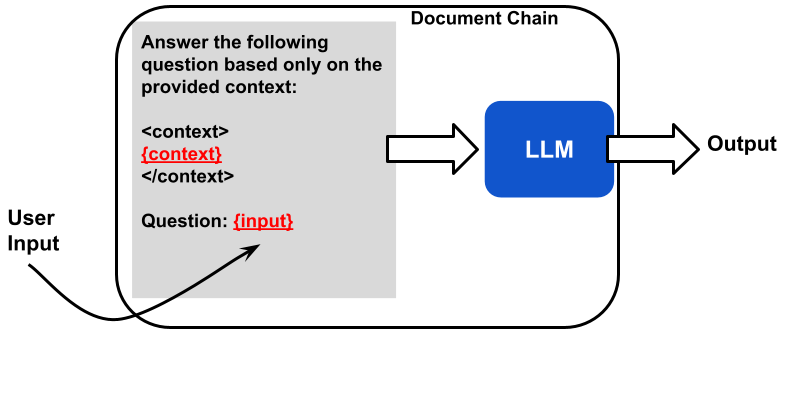

####Explanation:


- We're using the `create_stuff_documents_chain()` method, which builds a chain that:
  - Accepts a list of documents
  - "Stuffs" them into a prompt under the `<context>` section
  - Passes the complete prompt to the LLM

- The prompt is carefully structured:
  - It tells the LLM to **only answer using the provided context**
  - `{context}` gets replaced with the retrieved documents
  - `{input}` is the user’s question

- We also attach the `output_parser` to extract a clean text response from the LLM.

This chain is now ready to be combined with a retriever to form a full RAG pipeline.


### Creating the Full Retrieval Chain (RAG)


### 🖼 RAG in Action:


Here's what’s happening in the image:
- The **Retriever** finds relevant content for the user’s query
- This content is inserted into a prompt as `<context>`
- The **LLM** is instructed to answer the `{input}` question based **only** on that context

> In short: the LLM isn't guessing — it's being fed the right context just-in-time.

---

✅ With that mental model in place, let's start coding our way from a simple LLM call to a full working RAG chain.


Below is a simplified visual of what a RAG pipeline looks like:

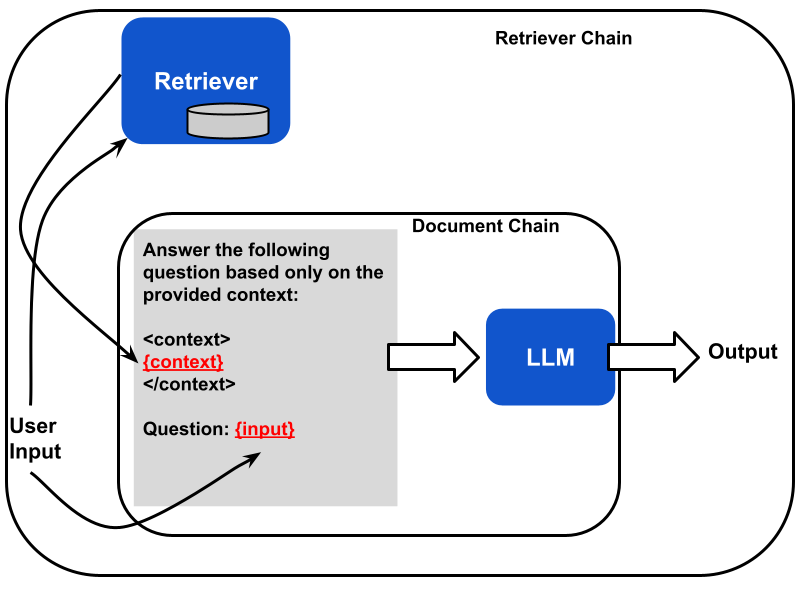

In [ ]:
# Import a helper function to create a retrieval-augmented generation (RAG) chain


# Convert the vector store into a retriever for performing similarity search
retriever = vector.as_retriever(
    search_type="similarity_score_threshold",
    search_kwargs={
        "k": 3,
        "score_threshold": 0.2
    }
)

# Create a retrieval chain that uses the retriever and a document-answering chain
retrieval_chain = create_retrieval_chain(retriever, document_chain) # context(retriver)| prompt | llm | output_parser

### Explanation:



- `vector.as_retriever()` converts the FAISS vector store into a **retriever**, which can search and return relevant document chunks based on a user query.

- `create_retrieval_chain()` then connects:
  - the **retriever** (to fetch relevant context),
  - and the **document chain** (to pass that context + question to the LLM).

Together, this forms a complete **Retrieval-Augmented Generation (RAG)** pipeline.

Now when you invoke this chain with a question, it will:
> 1. Retrieve relevant chunks,
> 2. Stuff them into a prompt,
> 3. And get a focused answer from the LLM based only on those documents.


In [ ]:
# Invoke the retrieval chain with a user query; it retrieves relevant documents and generates an answer
response = retrieval_chain.invoke({"input": "who is sachin tendulkar?"})

/usr/local/lib/python3.12/dist-packages/langchain_core/vectorstores/base.py:1048: UserWarning: Relevance scores must be between 0 and 1, got [(Document(id='7b0f1b23-fb1c-4382-b0bb-832ba32028bc', metadata={'source': 'https://docs.smith.langchain.com/', 'title': 'LangSmith Observability - Docs by LangChain', 'description': 'Instrument your LLM application, investigate traces, and monitor performance in production with LangSmith.', 'language': 'en'}, page_content='ObservabilityLangSmith Observability provides full visibility into your LLM application: from individual traces to production-wide performance metrics.LangSmith works with many frameworks and providers. Browse available integrations to connect your stack including OpenAI, Anthropic, CrewAI, Vercel AI SDK, Pydantic AI, and more.Get startedCreate an accountSign up at smith.langchain.com (no credit card required).'), np.float32(-0.28756785)), (Document(id='310852b8-413d-4b1b-8d36-c77d0df0f323', metadata={'source': 'https://docs.smi

This runs the full RAG chain with the question "how can langsmith help with testing?"
It retrieves relevant chunks from the LangSmith docs, passes them to the LLM, and prints the final answer.

In [ ]:
# Print the final answer generated by the retrieval chain
print(response["answer"])

No answer.


### Output Summary
The response is grounded in the actual documentation, highlighting LangSmith’s observability, feedback tools, and evaluation metrics — much more accurate and specific than generic answers earlier.

This shows the power of RAG: the LLM isn't guessing — it's answering based on real, retrieved content.

In [ ]:
# Invoke the retrieval chain with a follow-up question
response = retrieval_chain.invoke({"input": "how can I use langsmith?"})

# Print the generated answer, which should use context from previously retrieved documents
print(response["answer"])

To use LangSmith, you can start by creating an account at smith.langchain.com, where no credit card is required. After signing up, you can set up a LangSmith instance by choosing between cloud, hybrid, or self-hosted options. Each option includes features like observability, evaluation, prompt engineering, and deployment. Additionally, you can explore available integrations with various frameworks and providers to connect your stack. For more detailed guidance, refer to the documentation index available at /llms.txt.


In [ ]:
query = "what is langsmith?"

docs_with_scores = vector.similarity_search_with_relevance_scores(
    query,
    k=3,
    score_threshold = 0.2

)

for i, (doc, score) in enumerate(docs_with_scores, start=1):
    print(f"\n--- Chunk {i} ---")
    print("Score:", score)
    print("Content:")
    print(doc.page_content)
    print("Metadata:")
    print(doc.metadata)


--- Chunk 1 ---
Score: 0.41624123
Content:
LangSmith Observability - Docs by LangChainDocumentation IndexFetch the complete documentation index at: /llms.txtUse this file to discover all available pages before exploring further.Skip to main contentJoin our product experts for a "Build More with LangSmith: Summer AMA Series" from July 9-August 12, 2026. RSVP todayDocs by LangChain home pageMonitorSearch...⌘KAsk AIGitHubTry LangSmithTry LangSmithSearch...NavigationLangSmith ObservabilityOverviewEngineTraceDebugObserveLangSmith
Metadata:
{'source': 'https://docs.smith.langchain.com/', 'title': 'LangSmith Observability - Docs by LangChain', 'description': 'Instrument your LLM application, investigate traces, and monitor performance in production with LangSmith.', 'language': 'en'}

--- Chunk 2 ---
Score: 0.29297787
Content:
For trace pricing, retention, and limits, see Usage and billing.To set up a LangSmith instance, visit the Platform setup section to choose between cloud, hybrid, or se

Even though the question was vague ("How can I use it?"), the RAG setup still returned an accurate answer.
It understood what “it” referred to (LangSmith) by grounding the response in the retrieved documentation.

This demonstrates a key strength of RAG: the model doesn't have to guess — it uses retrieved context to resolve ambiguity and deliver relevant, specific answers.

-------------------------------------------

Saving and loading it back

In [ ]:
vector.save_local("faiss_index")

In [ ]:
from langchain_community.vectorstores import FAISS

vector = FAISS.load_local(
    "faiss_index",
    embeddings,
    allow_dangerous_deserialization=True
)

In [ ]:
retriever = vector.as_retriever(
    search_type="similarity_score_threshold",
    search_kwargs={
        "k": 3,
        "score_threshold": 0.2
    }
)

---

### 🧪 Try It Yourself: Hands-On Exercises
You've just built a working RAG pipeline using LangChain — from basic LLM calls all the way to retrieval-augmented answers over real documentation.

Try extending what you've learned with the following hands-on tasks:

---

### 1. 🔄 Modify the Prompt Style
Tweak the system prompt to change the LLM’s behavior. For example:
- Make it more concise
- Use a professional or casual tone
- Format answers as bullet points or numbered steps

💡 *Tip: Try instructing it to act like a teacher or a product manager.*

---

### 2. 🌐 Use a Different Source
Instead of the LangSmith docs, try building a RAG pipeline over:
- OpenAI documentation
- Hugging Face blog
- Any product’s FAQ page

🛠 Change the URL inside `WebBaseLoader`.

---

### 3. 🤔 Compare: RAG vs Raw LLM
Run the same question:
- Once using `llm.invoke(...)`  
- Then using the full `retrieval_chain.invoke(...)`

Notice how the RAG version gives more grounded and specific answers.

---

### 4. ✍️ Add Few-shot Examples
Try adding one or two sample Q&A pairs directly into the prompt template — this helps guide the model toward your desired answer style.

---

### 5. 🕵️ Inspect What’s Being Retrieved
Before the LLM responds, print out the retrieved chunks to see what content it's using.

```python
docs = retriever.get_relevant_documents("your question")
for d in docs:
    print(d.page_content[:300])



---
### 6. 💬 Build a Mini Q&A Bot (Bonus)
Turn your retrieval_chain.invoke() into a simple chatbot loop:

In [ ]:
while True:
    query = input("Ask something: ")
    if query.lower() in ["exit", "quit"]:
        break
    print(retrieval_chain.invoke({"input": query})["answer"])

KeyboardInterrupt: Interrupted by user

🧠 These exercises will help solidify your grasp on prompting, retrieval, and how to build useful tools on top of LLMs. Give them a shot!